# 040. 영화평 Text 분류 - 단어분리 (Subword Segmentation)

- WPM (Word Piece Model)
    - 하나의 단어를 내부단어 (Subword Unit) 들로 분리하는 단어 분리 모델
    - Google 번역기에서 사용
    

- IMDB (Internet Movie Database, https://www.imdb.com/)  Dataset


- Tensorflow tfds dataset 의 “imdb_reviews/subwords8k” 를 사용하여  “imdb_reviews”  사용시의 결과와 비교  


- 각 25,000 개의 training/testing set 으로 구성된 IMDB 영화관람평  


- “imdb_reviews/subwords8k” - 8,000 개의 subwords 로 사전 encoding 되어 있는 sequence data  


    -  “imdb_reviews” 는 encoding 되어있지 않은 string 형태의 data  
    -  Label : positive, negative binary classification
    
- single Bidirectional LSTM 과 stacked Bidirectional LSTM 두가지 model 비교

## imbd_reviews/subwords8k (pre-encoded data) 이용

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
import tensorflow_datasets as tfds
import numpy as np

dataset, info = tfds.load('imdb_reviews/subwords8k', with_info=True,as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

In [2]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    version=1.0.0,
    description='Large Movie Review Dataset.
This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well.',
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=2),
        'text': Text(shape=(None,), dtype=tf.int64, encoder=<SubwordTextEncoder vocab_size=8185>),
    }),
    total_num_examples=100000,
    splits={
        'test': 25000,
        'train': 25000,
        'unsupervised': 50000,
    },
    supervised_keys=('text', 'label'),
    citation="""@InProceedings{maas-EtAl:2011:ACL-HLT2011,
      author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Pot

### tfds 는  이미 encoding 되어 있는 tf.data.Dataset 을 return 하므로 data pipeline method 사용하여 sequence padding 을 한다.

In [3]:
encoder = info.features['text'].encoder

print('Vocabulary size: {}'.format(encoder.vocab_size))
print()
print(encoder.subwords[:100])

Vocabulary size: 8185

['the_', ', ', '. ', 'a_', 'and_', 'of_', 'to_', 's_', 'is_', 'br', 'in_', 'I_', 'that_', 'this_', 'it_', ' /><', ' />', 'was_', 'The_', 'as_', 't_', 'with_', 'for_', '.<', 'on_', 'but_', 'movie_', ' (', 'are_', 'his_', 'have_', 'film_', 'not_', 'ing_', 'be_', 'ed_', 'you_', ' "', 'it', 'd_', 'an_', 'he_', 'by_', 'at_', 'one_', 'who_', 'y_', 'from_', 'e_', 'or_', 'all_', 'like_', 'they_', '" ', 'so_', 'just_', 'has_', ') ', 'her_', 'about_', 'out_', 'This_', 'some_', 'ly_', 'movie', 'film', 'very_', 'more_', 'It_', 'would_', 'what_', 'when_', 'which_', 'good_', 'if_', 'up_', 'only_', 'even_', 'their_', 'had_', 'really_', 'my_', 'can_', 'no_', 'were_', 'see_', 'she_', '? ', 'than_', '! ', 'there_', 'get_', 'been_', 'into_', ' - ', 'will_', 'much_', 'story_', 'because_', 'ing']


In [4]:
for i, (input, label) in enumerate(dataset['test']):
    if i > 0:
        break
    print(f'label : {label}')
    print()
    print(input)
    print()
    print(encoder.decode(input))

label : 1

tf.Tensor(
[  69 5680   22  155 6819 7961 6197  309 2158 4551  192 4082    3  404
   12  117  129   44   14  344  506   38 4343 1846 8044   54    5 2974
  224 7968   40   35    4 4160  125   25  197   13 1268   38  433 2243
   23  601 2111  420   19   27  144  410   63 6864 5754 6088 3376 1270
  568   22  820  102 4378 3767 7968    8 7345    3 8002 7968  123  278
  270   30 1135 1911   36 1690  160  342   12  284 7374   21    5    1
 5110 4784    3 1156   72   12  321   61   42   18   20 5177    2   12
  270    1   27   18  215    7   35 6819    3   69  506    3   69   18
   67 6819 7961    5 3937 7961  614    7   35  581  161   44  242 4117
    3 2895   61  242 7979  391  714    3 1988 1758  295    2   53 1856
   25   13  606    3 2177 7837   83   77   35   11    1 1593  657    2
 4596 7961   39 7968    8    4  325 4743 7961 1223 5423  494    3  249
   97   20   12  270   15   18  149 1491    5   56    4 6819    2    1
   27 4853  192    5 2330   36  759 7653 7961 7993  726

In [5]:
BUFFER_SIZE = 10000
BATCH_SIZE = 32

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.padded_batch(BATCH_SIZE, train_dataset.output_shapes)

test_dataset = test_dataset.padded_batch(BATCH_SIZE, test_dataset.output_shapes)

Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(dataset)`.


Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(dataset)`.


## Single Bidirectional LSTM model

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(encoder.vocab_size, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          523840    
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               66048     
_________________________________________________________________
dense (Dense)                (None, 64)                8256      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 598,209
Trainable params: 598,209
Non-trainable params: 0
_________________________________________________________________


**steps_per_epoch**  
epoch 종료 전 batch iteration 수.  training set 의 size 가 고정되어 있는 경우 의미 없으나, large dataset 혹은 data augmentaion 을 할 경우 step 수를 제한할 수 있다.  training 시간 충분한 경우 parameter 지정 생략  


**validation_steps**  
steps_per_epoch 과 유사한 개념을 test data set 에 적용. 전체 validation set 을 처리할 시간 충분하면 parameter 생략

In [7]:
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset, validation_steps=30)

Epoch 1/5
782/782 [==============================] - 112s 143ms/step - loss: 0.5714 - accuracy: 0.6913 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 2/5
782/782 [==============================] - 105s 134ms/step - loss: 0.4870 - accuracy: 0.7769 - val_loss: 0.7381 - val_accuracy: 0.7146
Epoch 3/5
782/782 [==============================] - 106s 135ms/step - loss: 0.3884 - accuracy: 0.8411 - val_loss: 0.5054 - val_accuracy: 0.7677
Epoch 4/5
782/782 [==============================] - 105s 135ms/step - loss: 0.3129 - accuracy: 0.8761 - val_loss: 0.5181 - val_accuracy: 0.7823
Epoch 5/5
782/782 [==============================] - 105s 134ms/step - loss: 0.2556 - accuracy: 0.9010 - val_loss: 0.5198 - val_accuracy: 0.8208


In [8]:
import matplotlib.pyplot as plt

def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_' + metric])
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_' + metric])
    plt.show()

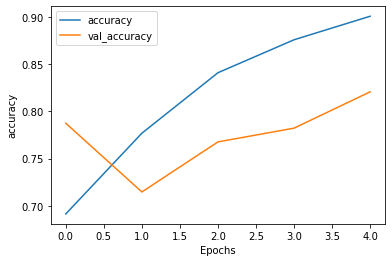

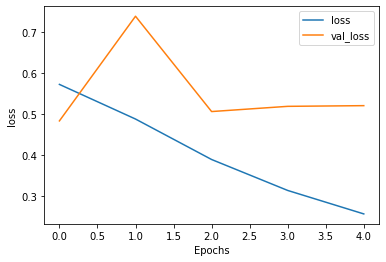

In [9]:
plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')

### 모델을 이용한 임의의 text 분류 감성 분류

prediction 이 >= 0.5 이면 positive 이고 else 이면 negative.

In [10]:
sample_pred_text = ('The movie was cool. The animation and the graphics '
                    'were out of this world. I would recommend this movie.')

encoded_sample_pred_text = encoder.encode(sample_pred_text)
encoded_sample_pred_text = tf.cast(encoded_sample_pred_text, tf.float32)
encoded_sample_pred_text

<tf.Tensor: id=22879, shape=(23,), dtype=float32, numpy=
array([1.900e+01, 2.700e+01, 1.800e+01, 2.724e+03, 3.000e+00, 1.900e+01,
       1.847e+03, 5.000e+00, 1.000e+00, 5.172e+03, 8.000e+00, 8.500e+01,
       6.100e+01, 6.000e+00, 1.400e+01, 5.620e+02, 3.000e+00, 1.200e+01,
       7.000e+01, 5.050e+02, 1.400e+01, 6.500e+01, 7.975e+03],
      dtype=float32)>

In [11]:
predictions = model.predict(tf.expand_dims(encoded_sample_pred_text, 0))
predictions

array([[0.6143507]], dtype=float32)

## stacked Bidirectional LSTM 으로 single LSTM 과 결과 비교

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(encoder.vocab_size, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [13]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 64)          523840    
_________________________________________________________________
bidirectional_1 (Bidirection (None, None, 128)         66048     
_________________________________________________________________
bidirectional_2 (Bidirection (None, 64)                41216     
_________________________________________________________________
dense_2 (Dense)              (None, 64)                4160      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 65        
Total params: 635,329
Trainable params: 635,329
Non-trainable params: 0
________________________________________________

In [14]:
history = model.fit(train_dataset, epochs=5,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/5
782/782 [==============================] - 205s 263ms/step - loss: 0.5674 - accuracy: 0.6750 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 2/5
782/782 [==============================] - 196s 250ms/step - loss: 0.3060 - accuracy: 0.8860 - val_loss: 0.3590 - val_accuracy: 0.8531
Epoch 3/5
782/782 [==============================] - 197s 252ms/step - loss: 0.2348 - accuracy: 0.9179 - val_loss: 0.3823 - val_accuracy: 0.8448
Epoch 4/5
782/782 [==============================] - 196s 251ms/step - loss: 0.1998 - accuracy: 0.9345 - val_loss: 0.4217 - val_accuracy: 0.8313
Epoch 5/5
782/782 [==============================] - 197s 252ms/step - loss: 0.1661 - accuracy: 0.9474 - val_loss: 0.4238 - val_accuracy: 0.8396


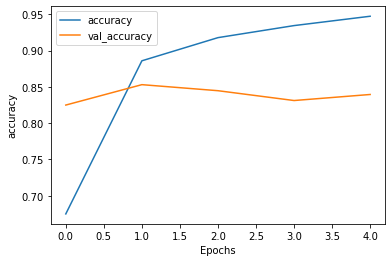

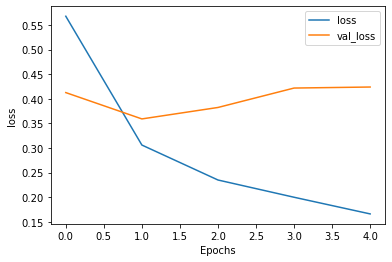

In [16]:
plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')

In [17]:
sample_pred_text = ('The movie was cool. The animation and the graphics '
                    'were out of this world. I would recommend this movie.')

encoded_sample_pred_text = encoder.encode(sample_pred_text)
encoded_sample_pred_text = tf.cast(encoded_sample_pred_text, tf.float32)
predictions = model.predict(tf.expand_dims(encoded_sample_pred_text, 0))
predictions

array([[0.5886074]], dtype=float32)